## Homogenized FHR model example.

In [ ]:
import openmc
import matplotlib.pyplot as plt
import numpy as np
openmc.Materials.cross_sections = '/home/jonathon/openmc_xs/endfb-vii.1-hdf5/cross_sections.xml'

def mat_from_stdcmp(mat: openmc.Material, file: str):
  """fills a material from stdcmp"""
  with open(file, 'r') as f:
    lines = f.readlines()[1:]
    for line in lines:
      splitted = line.split(' ')
      nuc = splitted[0]
      nuc = nuc.split('-')[0] + nuc.split('-')[1]
      nuc = nuc.capitalize()
      if nuc[-1] == 'm':
        continue
      if (nuc == 'C12') | (nuc == 'C13'):
        nuc = 'C0'
      val = float(splitted[3])
      mat.add_nuclide(nuclide=nuc, percent=val, percent_type='ao')

In [ ]:
"""Materials"""
f101 = openmc.Material(material_id=101, name='f101', temperature=900.0)
f102 = openmc.Material(material_id=102, name='f102', temperature=900.0)
f103 = openmc.Material(material_id=103, name='f103', temperature=900.0)
f104 = openmc.Material(material_id=104, name='f104', temperature=900.0)
f105 = openmc.Material(material_id=105, name='f105', temperature=900.0)
f106 = openmc.Material(material_id=106, name='f106', temperature=900.0)
f107 = openmc.Material(material_id=107, name='f107', temperature=900.0)
f108 = openmc.Material(material_id=108, name='f108', temperature=900.0)
f109 = openmc.Material(material_id=109, name='f109', temperature=900.0)
f110 = openmc.Material(material_id=110, name='f110', temperature=900.0)
f111 = openmc.Material(material_id=111, name='f111', temperature=900.0)
f112 = openmc.Material(material_id=112, name='f112', temperature=900.0)
f113 = openmc.Material(material_id=113, name='f113', temperature=900.0)
f114 = openmc.Material(material_id=114, name='f114', temperature=900.0)
f115 = openmc.Material(material_id=115, name='f115', temperature=900.0)
f116 = openmc.Material(material_id=116, name='f116', temperature=900.0)
mats_list = [f101,f102,f103,f104,f105,f106,f107,f108,f109,f110,f111,f112,f113,f114,f115,f116]
for mat in mats_list:
  mat_from_stdcmp(mat=mat, file=f"i3_p2_d2_triton_run_step_20_iter_0/StdCmpMix{mat.id}_")
  mat.set_density('sum')
  mat.add_s_alpha_beta(name='c_Graphite', fraction=1.0)

matPlena = openmc.Material(material_id=201, name='matPlena', temperature=900.0)
matPlena.add_nuclide('C0', percent=0.04512582, percent_type='ao')
matPlena.add_nuclide('Li6', percent=0.000000691507, percent_type='ao')
matPlena.add_nuclide('Li7', percent=0.0118566, percent_type='ao')
matPlena.add_nuclide('Be9', percent=0.00592865, percent_type='ao')
matPlena.add_nuclide('F19', percent=0.02371455, percent_type='ao')
matPlena.set_density('sum')

matFlibe = openmc.Material(material_id=301, name='matFlibe', temperature=900.0)
matFlibe.add_nuclide('Li6', percent=0.000001383014, percent_type='ao')
matFlibe.add_nuclide('Li7', percent=0.0237132, percent_type='ao')
matFlibe.add_nuclide('Be9', percent=0.0118573, percent_type='ao')
matFlibe.add_nuclide('F19', percent=0.0474291, percent_type='ao')
matFlibe.set_density('sum')

mats = openmc.Materials(materials= mats_list + [matPlena,matFlibe])
mats.export_to_xml()


In [ ]:
"""Geometry"""
h = 550.0/16
# TODO currently we just have fuel hexagons w/ no flibe need to compute side lengths of hexagons and then properly use box2 below as well.
edge_1 = 2*22.5/3**0.5
edge_2 = 2*23.4/3**0.5
uList = []

fuelPlanes = [openmc.ZPlane(z0=0.0)]
theH = 0.0
for this in range(16):
  fuelPlanes.append(openmc.ZPlane(z0=theH+34.375))
  theH += 34.375

box1 = openmc.model.HexagonalPrism(edge_length=edge_1)
box2 = openmc.model.HexagonalPrism(edge_length=edge_2, boundary_type='reflective')

plUpperPlena = openmc.ZPlane(z0=575.0)
plLowerPlena = openmc.ZPlane(z0=-25.0)

plBottom = openmc.ZPlane(z0=-75.0)
plUpper = openmc.ZPlane(z0=625.0)

plUpper.boundary_type = 'vacuum'
plBottom.boundary_type = 'vacuum'

flibeLower = openmc.Cell(cell_id=99, fill=matFlibe, region=(-box2 & +plBottom & -plLowerPlena))
unfueledLower = openmc.Cell(cell_id=100, fill=matPlena, region=(-box1 & +plLowerPlena & -fuelPlanes[0]))
c101 = openmc.Cell(cell_id=101, fill=f101, region=(-box1 & +fuelPlanes[0] &  -fuelPlanes[1]))
c102 = openmc.Cell(cell_id=102, fill=f102, region=(-box1 & +fuelPlanes[1] &  -fuelPlanes[2]))
c103 = openmc.Cell(cell_id=103, fill=f103, region=(-box1 & +fuelPlanes[2] &  -fuelPlanes[3]))
c104 = openmc.Cell(cell_id=104, fill=f104, region=(-box1 & +fuelPlanes[3] &  -fuelPlanes[4]))
c105 = openmc.Cell(cell_id=105, fill=f105, region=(-box1 & +fuelPlanes[4] &  -fuelPlanes[5]))
c106 = openmc.Cell(cell_id=106, fill=f106, region=(-box1 & +fuelPlanes[5] &  -fuelPlanes[6]))
c107 = openmc.Cell(cell_id=107, fill=f107, region=(-box1 & +fuelPlanes[6] &  -fuelPlanes[7]))
c108 = openmc.Cell(cell_id=108, fill=f108, region=(-box1 & +fuelPlanes[7] &  -fuelPlanes[8]))
c109 = openmc.Cell(cell_id=109, fill=f109, region=(-box1 & +fuelPlanes[8] &  -fuelPlanes[9]))
c110 = openmc.Cell(cell_id=110, fill=f110, region=(-box1 & +fuelPlanes[9] & -fuelPlanes[10]))
c111 = openmc.Cell(cell_id=111, fill=f111, region=(-box1 & +fuelPlanes[10] & -fuelPlanes[11]))
c112 = openmc.Cell(cell_id=112, fill=f112, region=(-box1 & +fuelPlanes[11] & -fuelPlanes[12]))
c113 = openmc.Cell(cell_id=113, fill=f113, region=(-box1 & +fuelPlanes[12] & -fuelPlanes[13]))
c114 = openmc.Cell(cell_id=114, fill=f114, region=(-box1 & +fuelPlanes[13] & -fuelPlanes[14]))
c115 = openmc.Cell(cell_id=115, fill=f115, region=(-box1 & +fuelPlanes[14] & -fuelPlanes[15]))
c116 = openmc.Cell(cell_id=116, fill=f116, region=(-box1 & +fuelPlanes[15] & -fuelPlanes[16]))
unfueledUpper = openmc.Cell(cell_id=117, fill=matPlena, region=(-box1 & -plUpperPlena & +fuelPlanes[-1]))
flibeUpper = openmc.Cell(cell_id=118, fill=matFlibe, region=(-box2 & -plUpper & +plUpperPlena))

flibeOutside = openmc.Cell(cell_id = 1, fill=matFlibe, region=(+box1 & -box2 & +plLowerPlena & -plUpperPlena))

fuelCells = [c101,c102,c103,c104,c105,c106,c107,c108,c109,c110,c111,c112,c113,c114,c115,c116]
uCombined = openmc.Universe(universe_id=1, cells=fuelCells + [flibeLower, unfueledLower, flibeUpper, unfueledUpper, flibeOutside])


geom = openmc.Geometry()
geom.root_universe = uCombined
geom.export_to_xml()

In [ ]:
uCombined.plot(basis='yz', width=[2.5,800.0], origin=(0.0, 0.0, 300), color_by='material')

In [ ]:

uCombined.plot(basis='xy', width=[60,60], pixels=250000)
plt.grid()

In [ ]:
"""Starting source and settings"""
# Make a point source at the center of the problem
# point = openmc.stats.Point((0.0,0.0,0.0))
spatial_dist = openmc.stats.Box((-5,-5,0.0), (5,5,550), only_fissionable=True)

# Define the starting source
source = openmc.IndependentSource(space=spatial_dist)
settings = openmc.Settings()
settings.source = source
settings.batches = 475
settings.inactive = 275
settings.particles = 300000
settings.temperature['method'] = 'interpolation'
settings.export_to_xml()

In [ ]:
"""Tallies"""
talls = []
for this in fuelCells:
  the_t = openmc.Tally(name=f'flux{this.id}', tally_id=this.id)
  the_t.scores = ['heating-local']
  the_t.filters = [
    openmc.CellFilter(bins=[this,])
  ]
  talls.append(the_t)

tallies = openmc.Tallies(tallies=talls)
tallies.export_to_xml()



In [ ]:
# Do the following to init() run() and finalize() results.
res = {}
import copy
import openmc.lib
openmc.lib.init()
openmc.lib.simulation_init()
for b in range(settings.batches):
  tallies = [openmc.lib.tallies[this.id] for this in talls]
  openmc.lib.next_batch()
  results = [tally.results for tally in tallies]
  res[b] = copy.deepcopy(results)
openmc.lib.simulation_finalize()
openmc.lib.finalize()

In [ ]:
"""
Open and save pickle file
"""
def tally_by_gen(res):
  shape0 = np.zeros(16)
  d = {}
  """nice little function to get tallies by gen"""
  for key in res.keys():
    shape1 = np.array([ this[:,:,1][0][0] for this in res[key][0:16] ])
    shape = shape1 - shape0
    d[key] = shape
    # advance
    shape0 = shape1
  return d

d = tally_by_gen(res)
for key in range(10,15):
  plt.plot(d[key])

import pickle as pkl
with open("data_step0.pkl", "wb") as file:
    pkl.dump(d, file)

### Part 2. setting up corrector

predictor P sum = 199.72919459


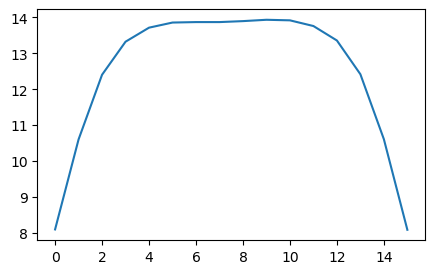

In [1]:
import matplotlib.pyplot as plt
import pickle as pkl
import numpy as np
import copy
# predicotr power from: PREDICTOR/step_19_ALL/combined_pred.inp
pred_P = np.array([8.10455956,10.6064514,12.40449474,13.3231417,13.713228,13.85547537,13.86836539,13.86828702,13.89530106,13.93247775,13.91676547,13.75879233,13.35664288,12.41803789,10.61241791,8.09475612])
pred_P_sum = pred_P.sum()
print("predictor P sum =",pred_P_sum)
plt.figure(figsize=(5,3))
plt.plot(pred_P)

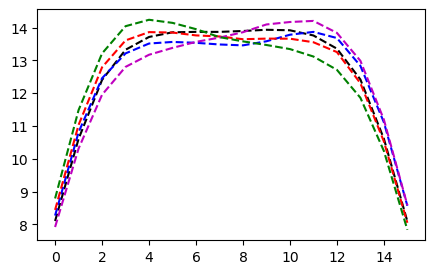

In [2]:
with open('data_step0_75k_EE.pkl', 'rb') as f:
  res0 = pkl.load(f)
with open('data_step1_75k_EE.pkl', 'rb') as f:
  res1 = pkl.load(f)
with open('data_step2_75k_EE.pkl', 'rb') as f:
  res2 = pkl.load(f)
with open('data_step3_75k_EE.pkl', 'rb') as f:
  res3 = pkl.load(f)

# Get P0 average
p0_tot = np.zeros(16)
for key in res0.keys():
  p0_tot += res0[key]
p0_tot = p0_tot / p0_tot.sum() * pred_P_sum

# Get P1 average
p1_tot = np.zeros(16)
for key in res1.keys():
  p1_tot += res1[key]
p1_tot = p1_tot / p1_tot.sum() * pred_P_sum

# Get P1 average
p2_tot = np.zeros(16)
for key in res2.keys():
  p2_tot += res2[key]
p2_tot = p2_tot / p2_tot.sum() * pred_P_sum

# Get P1 average
p3_tot = np.zeros(16)
for key in res3.keys():
  p3_tot += res3[key]
p3_tot = p3_tot / p3_tot.sum() * pred_P_sum

plt.figure(figsize=(5,3))
plt.plot(pred_P, 'k--')
plt.plot(p0_tot, 'b--')
plt.plot(p1_tot, 'r--')
plt.plot(p2_tot, 'm--')
plt.plot(p3_tot, 'g--')

In [3]:
# Printing power (averaged with predictor and p0)
for idx in range(16):
  vec = np.linspace(pred_P[idx], p0_tot[idx], 11)
  # print("power=", vec[1:]/2 + vec[0:-1]/2, f'% {idx}')
  print("power=", [float(p0_tot[idx])]*10, f'% {idx}')

power= [8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524, 8.270971312640524] % 0
power= [10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587, 10.809123760026587] % 1
power= [12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395, 12.456153013709395] % 2
power= [13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208, 13.21241358681208] % 3
power= [13.513300192772803, 13.513300192772803, 13.513300192772803, 13.513300192772803, 13.513300192772803, 13.513300192772803, 13.513300192772803, 13.513300192772803, 13.5

In [4]:
# Printing power (averaged with predictor and p1)
for idx in range(16):
  vec = np.linspace(pred_P[idx], p1_tot[idx], 11)
  # print("power=", vec[1:]/2 + vec[0:-1]/2, f'% {idx}')
  print("power=", [float(p1_tot[idx])]*10, f'% {idx}')

power= [8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687, 8.44284451273687] % 0
power= [11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773, 11.031989598315773] % 1
power= [12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415, 12.788675711959415] % 2
power= [13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883, 13.608519826834883] % 3
power= [13.860971203659163, 13.860971203659163, 13.860971203659163, 13.860971203659163, 13.860971203659163, 13.860971203659163, 13.860971203659163, 13.860971203659163, 13.8

In [5]:
# Printing power (averaged with predictor and p1)
for idx in range(16):
  vec = np.linspace(pred_P[idx], p1_tot[idx], 11)
  # print("power=", vec[1:]/2 + vec[0:-1]/2, f'% {idx}')
  print("power=", [float(p2_tot[idx])]*10, f'% {idx}')

power= [7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175, 7.922125332755175] % 0
power= [10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237, 10.31195456090237] % 1
power= [11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839, 11.952935809886839] % 2
power= [12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115, 12.801177412725115] % 3
power= [13.171265019946855, 13.171265019946855, 13.171265019946855, 13.171265019946855, 13.171265019946855, 13.171265019946855, 13.171265019946855, 13.171265019946855, 13.1

the matrix V is
[[0.10225894 0.03192546]
 [0.03192546 0.08976893]]
the correlation coeff =  0.3332142363964538
the matrix V is
[[0.11511897 0.01920534]
 [0.01920534 0.12578478]]
the correlation coeff =  0.15960060102908874
the matrix V is
[[ 0.11454248 -0.00130109]
 [-0.00130109  0.14170036]]
the correlation coeff =  -0.010212684309393795
the matrix V is
[[ 0.09954124 -0.02427566]
 [-0.02427566  0.20042016]]
the correlation coeff =  -0.17186946588063484
the matrix V is
[[ 0.09575359 -0.04945961]
 [-0.04945961  0.22028085]]
the correlation coeff =  -0.34055304614862336
the matrix V is
[[ 0.09097983 -0.03972904]
 [-0.03972904  0.18744204]]
the correlation coeff =  -0.3042299477160276
the matrix V is
[[ 0.10544358 -0.02847804]
 [-0.02847804  0.12544138]]
the correlation coeff =  -0.24761651250032016
the matrix V is
[[ 0.13712117 -0.00239971]
 [-0.00239971  0.10468074]]
the correlation coeff =  -0.02002963030758006
the matrix V is
[[ 0.13922584 -0.01371214]
 [-0.01371214  0.09112633]]
the 

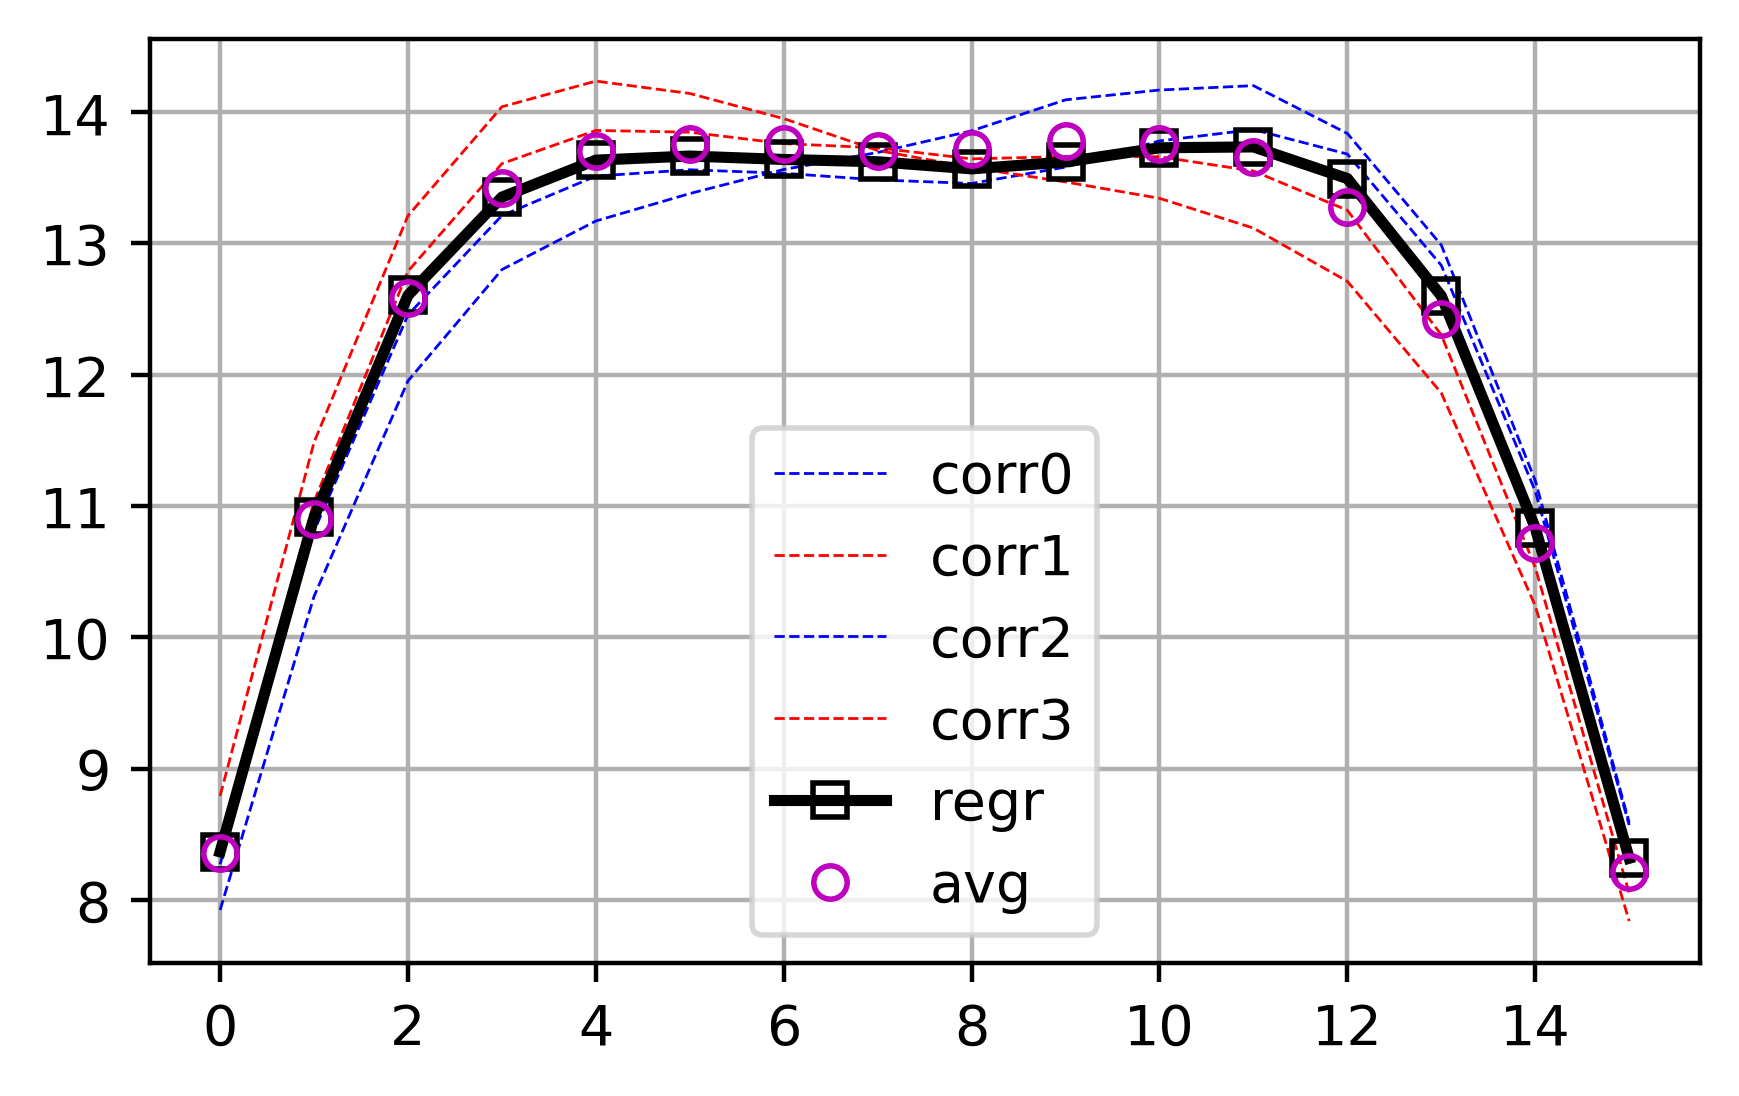

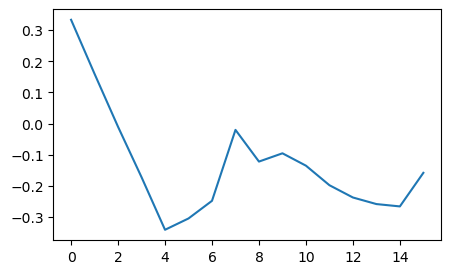

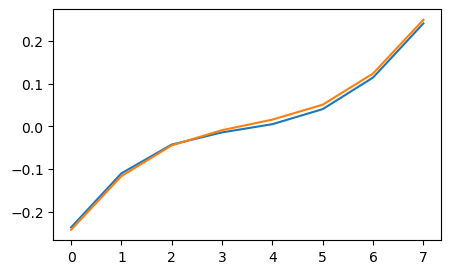

In [17]:
def group_batches(res: dict, M: int):
  """group batches based on input M"""
  if (len(list(res.keys())) % M) != 0:
    raise Exception("M must be multiple of max batches!")
  counter = 0
  res_new = {}
  tlly = copy.deepcopy(res[0])
  batchM = 0
  for key in res.keys():
    counter += 1
    tlly += res[key]
    if counter % M == 0:
      res_new[batchM] = tlly/M
      batchM += 1
      tlly = copy.deepcopy(res[0])
  return res_new

def normalize_res(res: dict, val: float):
  for key in res.keys():
    the_sum = np.sum(res[key])
    if the_sum == 0:
      res[key] = res[key]
    else:
      res[key] = res[key] / the_sum * val
  return res


def get_vij(N: int, start: int, F: list, I: list,
            i: int, j: int, f: int):
  Vij = 0.0
  for k in range(start,start+N):
    Vij += (F[i][k][f] - I[i][f])*(F[j][k][f] - I[j][f]) / (N-1)
  return Vij

def get_new_I(N: int, start: int,
              F: list, I: list,
              f: int):
  n = len(F)
  V = np.zeros((n,n))
  for i in range(n):
    for j in range(n):
      V[i,j] = get_vij(N=N, start=start, F=F, I=I, i=i, j=j, f=f) # returns vectror of Vij where each index is a fuel zone

  print("the matrix V is")
  print(V)
  if n == 2:
    # print correlation a and b
    coeff = V[1,0]/V[0,0]**0.5/V[1,1]**0.5
    print("the correlation coeff = ", coeff)
  else:
    coeff = 0
  the_I = np.array([[this[f] for this in I]]).transpose() # col vec of my best estimates.
  X = np.ones((n,1)) # col vec of ones.
  new_I = np.linalg.inv(X.transpose() @ np.linalg.inv(V) @ X) @ X.transpose() @ np.linalg.inv(V) @ the_I
  return new_I, coeff

# Normalize each res to predictor power value
res0 = normalize_res(res0, pred_P_sum)
res1 = normalize_res(res1, pred_P_sum)
res2 = normalize_res(res2, pred_P_sum)
res3 = normalize_res(res3, pred_P_sum)

# I & F
I3 = p3_tot
I2 = p2_tot
I1 = p1_tot
I0 = p0_tot

# I = [I0, I1, I2, I3]
# F = [res0, res1, res2, res3]
I = [I0, I1]
F = [res0, res1]


new = []
coeffs = []
for this in range(16):
  new_I, coeff = get_new_I(N=200, start=275, F=F, I=I, f=this)
  coeffs.append(coeff)
  new.append(new_I[0][0])

plt.figure(figsize=(5,3), dpi=400)
# plt.plot(pred_P, 'k--', linewidth=0.5)
plt.plot(p0_tot, 'b--', linewidth=0.5, label='corr0')
plt.plot(p1_tot, 'r--', linewidth=0.5, label='corr1')
plt.plot(p2_tot, 'b--', linewidth=0.5, label='corr2')
plt.plot(p3_tot, 'r--', linewidth=0.5, label='corr3')
plt.plot(new, 'ks-', markerfacecolor='none', label='regr', linewidth=2)

# avg = (p0_tot/4 + p1_tot/4 + p2_tot/4 + p3_tot/4)
avg = (p2_tot/2 + p3_tot/2)
plt.plot(avg, 'mo', markerfacecolor='none', label='avg', linewidth=2)
plt.legend()
plt.grid()

plt.figure(figsize=(5,3))
plt.plot(coeffs)

plt.figure(figsize=(5,3))
plt.plot(  (np.array(new[0:8]) - np.array(new[8:]))  / ((np.array(new[0:8]) + np.array(new[8:]))) )
plt.plot(  (np.array(avg[0:8]) - np.array(avg[8:]))  / ((np.array(avg[0:8]) + np.array(avg[8:]))) )

print('regression method AO =',(sum(new[0:8]) - sum(new[8:]) )/ sum(new))
print('wgt avg AO =', ( sum(avg[0:8]) - sum(avg[8:]) ) / sum(avg))



In [7]:
res_test = group_batches(res0, M=5)

In [8]:
res_test

{0: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 1: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 2: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 3: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 4: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 5: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 6: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 7: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 8: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 9: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 10: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 11: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 12: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

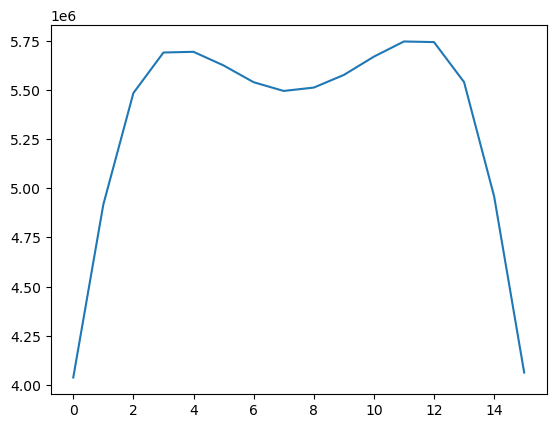

In [9]:
hl = [4.03795e+06,
4.91754e+06,
5.4845e+06 ,
5.69079e+06,
5.69425e+06,
5.62495e+06,
5.53962e+06,
5.49525e+06,
5.51237e+06,
5.57654e+06,
5.66963e+06,
5.74685e+06,
5.7437e+06 ,
5.54034e+06,
4.95932e+06,
4.06308e+06]
plt.plot(hl)

In [10]:
new_I

array([[8.31652415]])

In [11]:
new_I = np.linalg.inv(X.transpose() @ np.linalg.inv(V) @ X) @ X.transpose() @ np.linalg.inv(V) @ the_I

NameError: name 'X' is not defined

In [ ]:
the_I = np.array([this[f] for this in I]).transpose()

In [ ]:
the_I

In [ ]:
X.transpose()

In [ ]:
X

In [ ]:
Fik

In [ ]:
F

In [ ]:
Fik

In [ ]:
# LOGIC on HPC
# We have obtained step 20 T0 comp using:
# PREDICTOR/step_19_ALL/combined_pred.inp
# Thus we need to correct using these predictor powers + step0 from this openmc run
#   For corrector use